# TP-GNN
To get started, you need to install pytorch geometric:
- https://pytorch-geometric.readthedocs.io/en/latest/install/installation.html.

You can then have a look at the tutorial:
- https://pytorch-geometric.readthedocs.io/en/latest/get_started/introduction.html.

Check in particular sections:
- Data Handling of Graphs
- Data Transforms
- Learning Methods on Graphs

don't hesitate to check [practical slides](./GCNcode.pdf)

In [50]:
import matplotlib.pyplot as plt
import networkx as nx
import seaborn as sns
import torch as th
import torch.nn.functional as F
from matplotlib.cm import ScalarMappable
from sklearn.manifold import TSNE
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import LabelEncoder
from torch import nn
from torch_geometric.nn import VGAE, GCNConv
from torch_geometric.transforms import RandomLinkSplit
from torch_geometric.utils import from_networkx, to_networkx


## Getting started

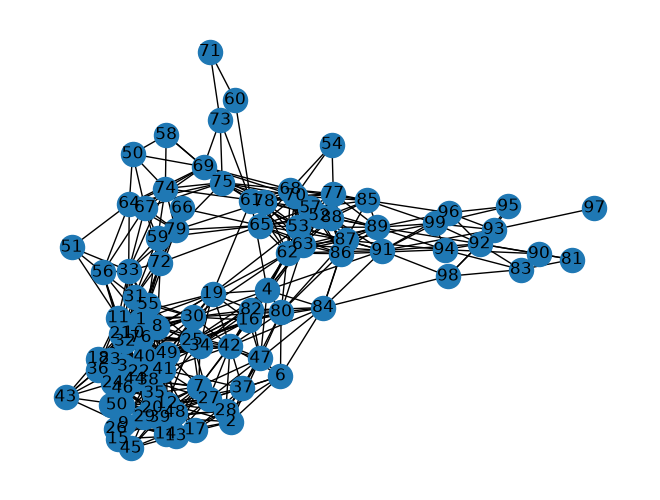

[(0, {'name': 'Student_0', 'club': 'Sports', 'like_sports': 0.7955415097609702, 'like_music': 0.22092986130263698, 'like_science': 0.043229593031232666}), (1, {'name': 'Student_1', 'club': 'Sports', 'like_sports': 0.5391393734668835, 'like_music': 0.4639886213674777, 'like_science': 0.10628242488369519}), (2, {'name': 'Student_2', 'club': 'Sports', 'like_sports': 0.7570436693055108, 'like_music': 0.01738607217224325, 'like_science': 0.44273534523038927}), (3, {'name': 'Student_3', 'club': 'Sports', 'like_sports': 0.788508191930243, 'like_music': 0.5265848394724645, 'like_science': 0.19326163051929218}), (4, {'name': 'Student_4', 'club': 'Sports', 'like_sports': 0.485804022702344, 'like_music': 0.4568754444233814, 'like_science': 0.49032284631155887}), (5, {'name': 'Student_5', 'club': 'Sports', 'like_sports': 0.7096290234245467, 'like_music': 0.16079924755089806, 'like_science': 0.006686683810232519}), (6, {'name': 'Student_6', 'club': 'Sports', 'like_sports': 0.4637126458429731, 'like

In [87]:
# (a) Load the toy dataset ToyFriendship.graphml from the class website, using networkx. Plot the
# network to have a quick view, check the attributes print(G.nodes(data=True)). Node are students,
# edges correspond to friendships, and we know the tastes of the students among sports/music/science.
# We also know to which club they belong to in their university.
# take care to turn node_type=int
# https://networkx.org/documentation/stable/reference/index.html

# chargement graphe + conversion noeuds en int
G = nx.read_graphml("../graphes/student_graph.graphml",node_type=int)

# apercu visuel
nx.draw(G, with_labels=True)
plt.show()

print(G.nodes(data=True))



In [52]:
# (b) Convert from networkx to pytorch geometric using torch geometric.utils.from_networkx function. 
# In the function, use group_node_attrs=["like_sports", "like_music", "like_science"] 
# to load only those attributes as x.
# https://pytorch-geometric.readthedocs.io/en/latest/index.html

# conversion du graphe 
data = from_networkx(
    G, group_node_attrs=["like_sports", "like_music", "like_science"]
)

# x contient matrice 
print("Data: ")
print(data)
print("\n")
print("Data.x: ")
print(data.x)

# edge_index = nb de liens entre les noeuds (amitiés)
# name = nb de noeuds (donc étudiants)
# club = classe attribué a chaque noeud (club de chaque étu)
# x = matrice des caractéristiques (pourcentage de likeness de chaque étu
# par rapport à un club)

Data: 
Data(edge_index=[2, 1356], name=[100], club=[100], x=[100, 3])


Data.x: 
tensor([[7.9554e-01, 2.2093e-01, 4.3230e-02],
        [5.3914e-01, 4.6399e-01, 1.0628e-01],
        [7.5704e-01, 1.7386e-02, 4.4274e-01],
        [7.8851e-01, 5.2658e-01, 1.9326e-01],
        [4.8580e-01, 4.5688e-01, 4.9032e-01],
        [7.0963e-01, 1.6080e-01, 6.6867e-03],
        [4.6371e-01, 6.7684e-02, 4.6283e-01],
        [7.8664e-01, 2.9709e-01, 3.8989e-01],
        [5.0010e-01, 3.6287e-01, 1.0783e-01],
        [8.7970e-01, 1.7788e-01, 1.2040e-01],
        [5.3466e-01, 3.7802e-01, 0.0000e+00],
        [6.5995e-01, 5.9280e-01, 1.3134e-01],
        [7.6446e-01, 1.6210e-01, 1.9845e-01],
        [8.9997e-01, 9.2499e-02, 2.4825e-01],
        [9.1519e-01, 1.3469e-01, 2.7405e-01],
        [7.5238e-01, 9.4697e-03, 2.0946e-02],
        [5.1735e-01, 4.1870e-01, 4.1152e-01],
        [4.3422e-01, 6.9311e-02, 1.3107e-01],
        [8.0739e-01, 4.6717e-01, 2.5192e-02],
        [4.9686e-01, 5.4837e-01, 3.1980e-01],

In [53]:
# (c) Check what is inside this object. You should find the edges edge_index, 
# the node features x , etc...

# 1. apercu general
print("- Apercu general:", data)

# 2. matrice d'adjacence / liste des arêtes [2, num_edges]
print("\n- Matrice d'adjacence :")
print(data.edge_index)
# premiere ligne = les noeuds
# deuxieme ligne du meme index = noeuds connectés avec
# [0,0,1]
# [2,7,2] => 0 connecté avec 2 et 7
print("- Forme de edge_index :", data.edge_index.shape)
print(" => On a ",data.edge_index.shape[1]," liens au total")

# 3. matrice des caractéristiques des nœuds [num_nodes, num_features]
if hasattr(data, 'x') and data.x is not None:
    print("\n- Matrice des caractéristiques (x) :")
    print(data.x)
    print("Forme de x :", data.x.shape)
# [% de likeness de sport, % music, % science]

# 4. liste de toutes les clés d'attributs contenues dans l'objet
print("\n- Clés disponibles dans l'objet Data :", data.keys())

# 5.résumé 
print(f"\n- Nombre de nœuds : {data.num_nodes}")
print(f"- Nombre d'arêtes : {data.num_edges}")
print(f"- Contient des nœuds isolés : {data.has_isolated_nodes()}")
print(f"- Contient des boucles (self-loops) : {data.has_self_loops()}")
print(f"- Est un graphe non orienté : {data.is_undirected()}")

- Apercu general: Data(edge_index=[2, 1356], name=[100], club=[100], x=[100, 3])

- Matrice d'adjacence :
tensor([[ 0,  0,  0,  ..., 99, 99, 99],
        [ 5,  9, 12,  ..., 94, 95, 96]])
- Forme de edge_index : torch.Size([2, 1356])
 => On a  1356  liens au total

- Matrice des caractéristiques (x) :
tensor([[7.9554e-01, 2.2093e-01, 4.3230e-02],
        [5.3914e-01, 4.6399e-01, 1.0628e-01],
        [7.5704e-01, 1.7386e-02, 4.4274e-01],
        [7.8851e-01, 5.2658e-01, 1.9326e-01],
        [4.8580e-01, 4.5688e-01, 4.9032e-01],
        [7.0963e-01, 1.6080e-01, 6.6867e-03],
        [4.6371e-01, 6.7684e-02, 4.6283e-01],
        [7.8664e-01, 2.9709e-01, 3.8989e-01],
        [5.0010e-01, 3.6287e-01, 1.0783e-01],
        [8.7970e-01, 1.7788e-01, 1.2040e-01],
        [5.3466e-01, 3.7802e-01, 0.0000e+00],
        [6.5995e-01, 5.9280e-01, 1.3134e-01],
        [7.6446e-01, 1.6210e-01, 1.9845e-01],
        [8.9997e-01, 9.2499e-02, 2.4825e-01],
        [9.1519e-01, 1.3469e-01, 2.7405e-01],
        

In [54]:
# (d) Encode the class (club) using sklearn LabelEncoder 

encoder = LabelEncoder()
integer_labels = encoder.fit_transform(data.club)
target_tensor = th.tensor(integer_labels, dtype=th.long)
print("- target_tensor: ", target_tensor)
data.y = target_tensor
data.num_classes = len(set(data.club))

print("\n- Nombre de classes :", data.num_classes)

# correspondance entre le numéro encodé et le nom du club
print("\n- Correspondance des classes :")
for index, club_name in enumerate(encoder.classes_):
  print(f"  Code {index} -> {club_name}")


- target_tensor:  tensor([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1])

- Nombre de classes : 3

- Correspondance des classes :
  Code 0 -> Music
  Code 1 -> Science
  Code 2 -> Sports


In [55]:
# (e) Let’s consider that for some of the students, we don’t know their preferences, but we want to
# train a model to guess the club they belong to. For instance, we can imagine new students to whom
# we want to recommend a club. So we want to guess the club class from the like attributes, but
# for students for which we don’t have the like attribute. Without graph, this is not possible.
# We need to hide the like information for some of the nodes. You can do it with a mask, with
# something like:

num_nodes = data.num_nodes
train_ratio = 0.80 # 80% of nodes for training

# Randomly creating a mask
mask = th.rand(num_nodes) < train_ratio
print("masks: ", mask.shape, mask.sum())
data.train_mask = mask
data.test_mask = ~data.train_mask
    
# remove the attributes for the nodes that are not in the training set
temp = th.zeros((num_nodes, 3), dtype=th.float)
temp[data.train_mask] = data.x[data.train_mask]
data.x = temp
data

# en gros on train sur 80% des etu
# puis on supp les données des 20% des autres étu
# et grace aux liens (edge_index) on essaie de deviner les clubs 

masks:  torch.Size([100]) tensor(80)


Data(edge_index=[2, 1356], name=[100], club=[100], x=[100, 3], y=[100], num_classes=3, train_mask=[100], test_mask=[100])

## Predict using a GCN

In [56]:
# (a) Build your first GCN, with a single layer. It should solve a classification problem, with 3 classes.

class Model(nn.Module):
    """Graph Convolutional network"""
    def __init__(self, dim_in, dim_out):
        super().__init__()
        self.gcn1 = GCNConv (dim_in, dim_out) #add_self_loops=False

    def forward(self, x, edge_index):
        h = self.gcn1(x,edge_index)
        return F.log_softmax(h, dim=1)

def train(data, model, epochs):
    criterion = th.nn.NLLLoss() #CrossEntropyLoss()
    optimizer = th.optim.Adam(
        model.parameters(), lr=0.01, weight_decay=5e-4
        )

    model.train()

    for epoch in range(1, epochs + 1):
        optimizer.zero_grad()
        out = model(data.x, data.edge_index)
        loss = criterion(out[data.train_mask], data.y[data.train_mask])
        loss.backward()
        optimizer.step()

        if epoch % 10 == 0 or epoch == 1:
            print(f'Epoch {epoch:03d} | Loss: {loss.item():.4f}')


In [57]:
# (b) Your evaluation should be only on the test set, i.e., something like:
def test(data, model):
    pred = model(data.x, data.edge_index).argmax(dim=1)
    test_acc = (pred[data.test_mask] == data.y[data.test_mask]).sum() / data.test_mask.sum()
    print(f"test_acc: {test_acc:4f}")
    return pred

In [58]:
# here instanciate the model, then train and test it
# Instanciation
model = Model(dim_in=data.x.shape[1], dim_out=3)

# Entraînement sur 100 époques
train(data, model, epochs=100)

Epoch 001 | Loss: 1.1571
Epoch 010 | Loss: 1.0828
Epoch 020 | Loss: 1.0187
Epoch 030 | Loss: 0.9647
Epoch 040 | Loss: 0.9174
Epoch 050 | Loss: 0.8752
Epoch 060 | Loss: 0.8371
Epoch 070 | Loss: 0.8023
Epoch 080 | Loss: 0.7703
Epoch 090 | Loss: 0.7407
Epoch 100 | Loss: 0.7133


(c) Check the add self loops attributes of the conv layer, and think of its meaning

In [59]:
print("add_self_loops est activé ? :", model.gcn1.add_self_loops)

add_self_loops est activé ? : True



== PENDANT LE TRAIN ==

- Quand add_self_loops = True : le modèle apprend grace a 2 points:
    - si l'étu aime le sport, alors il est dans le club sport
    - si ses amis aime le sport, "_____________________"
    -> epoch0 : nb de loss faible , epoch 100 : chute considérable

- Quand il est False : le modèle apprend uniquement grace aux amies
de l'étudiant, donc c'est moins efficace.
    -> epoch0 : nb de loss + élevé , epoch 100 : chute moins

=> Loss represente le poids des erreurs

In [60]:
# (d) Print the targets and the predictions for all the nodes

model.eval()
with th.no_grad():
  pred = model(data.x, data.edge_index).argmax(dim=1)

print("- Targets (vraies classes) :")
print(data.y)

print("\n- Predictions :")
print(pred)

# calcul et affichage du pourcentage
total = data.num_nodes
bonnes = (pred == data.y).sum().item()
mauvaises = total - bonnes

taux_reussite = (bonnes / total) * 100
taux_erreur = (mauvaises / total) * 100

print(
    f"\n => Résultat : {bonnes}/{total} bonnes réponses"
)



- Targets (vraies classes) :
tensor([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1])

- Predictions :
tensor([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 0, 2, 0, 0, 0, 2, 2, 0, 2, 2, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0,
        2, 0, 0, 0, 2, 0, 0, 2, 2, 1, 2, 1, 2, 0, 2, 0, 0, 0, 1, 1, 1, 1, 1, 1,
        1, 2, 1, 1])

 => Résultat : 82/100 bonnes réponses


<Axes: >

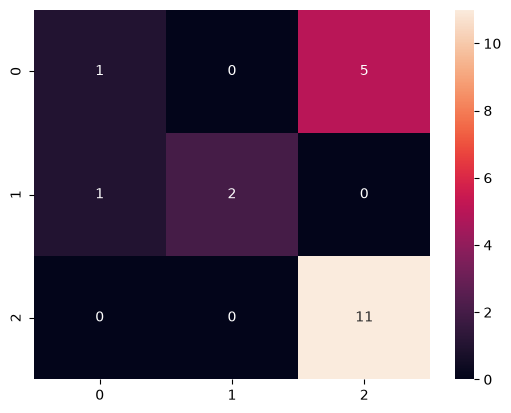

In [61]:
# (e) Plot a confusion matrix:
confmat = confusion_matrix(data.y[data.test_mask], pred[data.test_mask])
sns.heatmap(confmat, annot=True, fmt='g')

In [62]:
# (f) Print the weights of the GCN layer and interpret them (if you have a good accuracy...)
weights = model.gcn1.lin.weight  

print("Poids de la couche GCN (shape :", weights.shape, ") :")
print(weights)

Poids de la couche GCN (shape : torch.Size([3, 3]) ) :
Parameter containing:
tensor([[-0.0767,  2.0467, -0.4895],
        [-0.6520, -1.3623,  0.9807],
        [ 0.6479, -0.3154, -1.5827]], requires_grad=True)


Ca represente quelle indice impact le + le choix du club d'un élève.

    - ([club 0], [club 1], [club 3])
    - de la forme ([sport,musique,science], [sp,m,sc], [sp,m,sc])
    - ([-2,0,2],[...],[...]) 
            -> -2 : si il aime sport, surtout pas au club 0
            -> 2 : si il aime musique, forte chance d'etre au club 0

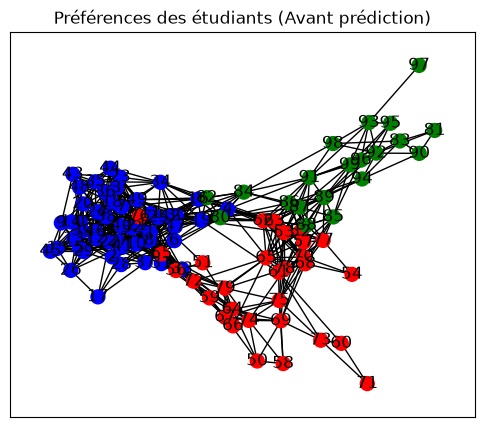

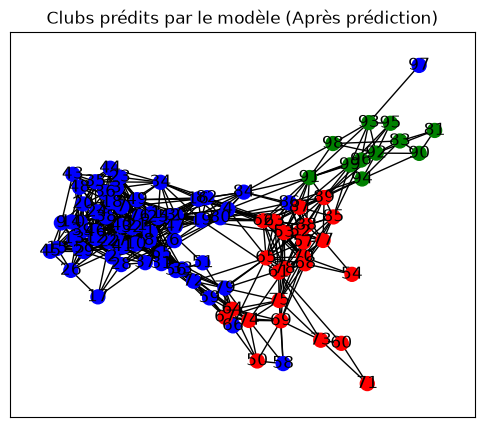

In [63]:
# (g) Print the network using networkx, with node colors corresponding first to student’s preference, then
# to nodes clubs, before and after prediction, to observe intuitively that the results are convincing.
# Here is an example to guide you

# conversion du graphe et disposition des nœuds
G = to_networkx(data, to_undirected=True)
pos = nx.spring_layout(G, seed=42)

# récupération des prédictions du modèle
model.eval()
with th.no_grad():
    pred = model(data.x, data.edge_index).argmax(dim=1)

# dictionnaire de correspondance 
club_names = {0: 'Sports', 1: 'Music', 2: 'Science'}

def afficher_graphe(liste_attributs, titre):
    # on assigne les attributs
    noms_c = [club_names[val.item()] for val in liste_attributs]
    nx.set_node_attributes(G, dict(zip(G.nodes(), noms_c)), 'club')
    
    colors = []
    for node in G.nodes(data=True):
        club = node[1].get('club')
        if club == 'Sports':
            colors.append('red')
        elif club == 'Music':
            colors.append('green')
        else:
            colors.append('blue')

    plt.figure(figsize=(6, 5))     
    nx.draw_networkx(G, pos=pos, with_labels=True, width=1, node_size=100, node_color=colors)
    plt.title(titre)
    plt.show()


afficher_graphe(data.y, "Préférences des étudiants (Avant prédiction)")

afficher_graphe(pred, "Clubs prédits par le modèle (Après prédiction)")

## Predicting edges using a VGAE

In [64]:
# (a) This time, we want to predict edges. Start back from the original network, without hidden information.


In [72]:
# Build a train test split using the RandomLinkSplit class
# You don’t need a validation set, the graph is undirected 
# and we have to split labels to easily differentiate positive edges from negative edges
# https://pytorch-geometric.readthedocs.io/en/latest/generated/torch_geometric.transforms.RandomLinkSplit.html#torch_geometric.transforms.RandomLinkSplit
transform = RandomLinkSplit(
    num_val=0.1,          # 10% des arêtes cachées pour la validation
    num_test=0.2,         # 20% des arêtes cachées pour le test final
    is_undirected=True,   
    split_labels=True,
    add_negative_train_samples=False 
)

# train_data contient le graphe avec certaines arêtes masquées (pour apprendre)
# val_data et test_data contiennent les arêtes masquées (pour vérifier)
train_data, val_data, test_data = transform(data)

print("Arêtes pour l'entraînement :", train_data.pos_edge_label_index.shape[1])
print("Arêtes cachées pour le test :", test_data.pos_edge_label_index.shape[1])

Arêtes pour l'entraînement : 476
Arêtes cachées pour le test : 135


In [ ]:
# (b) Build your Encoder which compute mu and logstd of a distribution
# and the train function associated
class Encoder(nn.Module):
    def __init__(self, dim_in, dim_out) :
          super().__init__()
          self.conv1 = GCNConv(dim_in, 2 * dim_out)
          self.conv_mu = GCNConv(2 * dim_out, dim_out) # moyenne
          self.conv_logstd = GCNConv(2 * dim_out, dim_out) # ecart-type

    def forward(self, x, edge_index) :
     x = self.conv1(x, edge_index).relu()
     return self.conv_mu(x, edge_index), self.conv_logstd(x, edge_index)
     
    
def train(model, data, epochs):
    model.train()
    optimizer.zero_grad()
    z = model.encode(train_data.x, train_data.edge_index)
    loss = model.recon_loss(z, train_data.pos_edge_label_index) + (1/ train_data.num_nodes) * model.kl_loss()
    loss.backward()
    optimizer.step()
    return float(loss)

In [78]:
# (c) Initialize your model using VGAE from torch geometric.nn, then train it
dim_in = data.num_features  # le nombre de caractéristiques initiales des nœuds
dim_out = 16  # la taille de l'espace abstrait réduit 

# initialisation 
encodeur = Encoder(dim_in, dim_out)
model = VGAE(encodeur)
optimizer = th.optim.Adam(model.parameters(), lr=0.01)

# boucle de training
epochs = 100
for epoch in range(1, epochs + 1):
    loss = train(model, train_data, epoch) 
    if epoch % 10 == 0 or epoch == 1:
        print(f'Epoch {epoch:03d} | Loss: {loss:.4f}')


Epoch 001 | Loss: 3.4767
Epoch 010 | Loss: 2.1215
Epoch 020 | Loss: 1.4432
Epoch 030 | Loss: 1.3538
Epoch 040 | Loss: 1.2800
Epoch 050 | Loss: 1.2622
Epoch 060 | Loss: 1.2392
Epoch 070 | Loss: 1.2606
Epoch 080 | Loss: 1.3071
Epoch 090 | Loss: 1.2828
Epoch 100 | Loss: 1.2489


In [79]:
# (d) Evaluate your model. Be careful to use training data for training and testing data for testing :)
# Something like:
z = model.encode(train_data.x, data.edge_index)
model.test(z, test_data.pos_edge_label_index, test_data.neg_edge_label_index)  # it give AUC and AP

(0.8168998628257887, 0.8053559695087807)

In [81]:
# (e) Check that you are able to reconstruct the original graph, by applying the dot product between
# node vectors. You can do it with something like:
pred_scores = th.sigmoid((z[test_data.pos_edge_label_index[0]] * z[test_data.pos_edge_label_index[1]]).sum(dim=1)).detach().numpy()

# how many edge are predicted with a score upon 0.5 ?
nombre_aretes_predites = (pred_scores > 0.5).sum()

print(f"Nombre d'arêtes prédites avec un score > 0.5 : {nombre_aretes_predites}")
print(f"Sur un total de : {len(pred_scores)} arêtes testées")

Nombre d'arêtes prédites avec un score > 0.5 : 127
Sur un total de : 135 arêtes testées


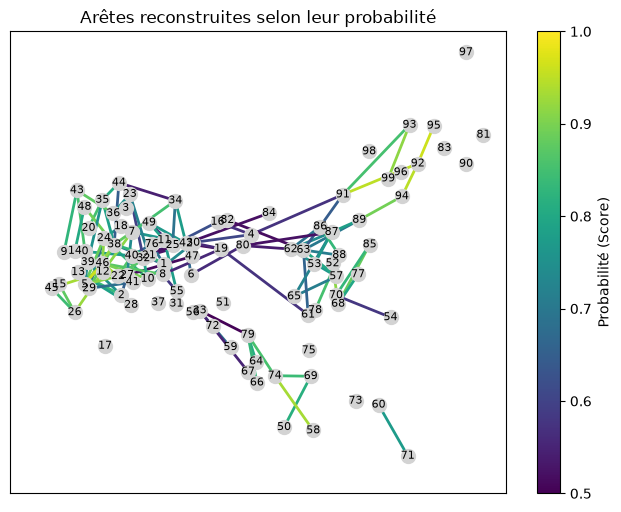

In [83]:
# (f) Using networkx, plot the original network, plus some of the edges considered as the most likely.
# You can use a color scale to represent the likeliness of observing an edge
test_data.edge_index = test_data.pos_edge_label_index
new_G = to_networkx(test_data, to_undirected=True)

edges_to_draw = []
edge_colors = []

for i in range(len(pred_scores)):
    # les arêtes considérées comme probables (score > 0.5)
    if pred_scores[i] > 0.5:
        u = int(test_data.pos_edge_label_index[0, i])
        v = int(test_data.pos_edge_label_index[1, i])
        edges_to_draw.append((u, v))
        edge_colors.append(pred_scores[i])


plt.figure(figsize=(8, 6))

# on dessine les nœuds d'abord
nx.draw_networkx_nodes(new_G, pos=pos, node_size=100, node_color='lightgray')
nx.draw_networkx_labels(new_G, pos=pos, font_size=8)

edges = nx.draw_networkx_edges(
    new_G, 
    pos=pos, 
    edgelist=edges_to_draw, 
    edge_color=edge_colors, 
    edge_cmap=plt.cm.viridis,  # du violet (0.5) au jaune (1.0)
    edge_vmin=0.5,             
    edge_vmax=1.0,             
    width=2.0
)

plt.colorbar(edges, label="Probabilité (Score)")
plt.title("Arêtes reconstruites selon leur probabilité")
plt.show()

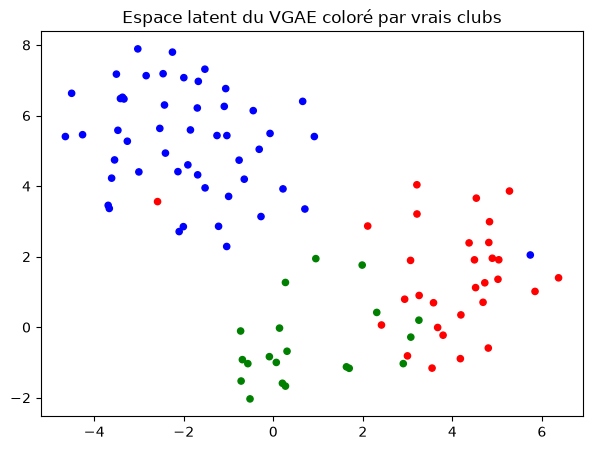

In [85]:
# (g) with TSNE we can visualize the sampled latent space of our VGAE.
# add color of classes to understand if its a meaningful representation or not
z_2d = TSNE(n_components=2, random_state=42).fit_transform(z.detach())

color_map = {0: 'red', 1: 'green', 2: 'blue'}
colors = [color_map[label.item()] for label in data.y]

plt.figure(figsize=(7, 5))
plt.scatter(z_2d[:, 0], z_2d[:, 1], c=colors, s=20)
plt.title("Espace latent du VGAE coloré par vrais clubs")
plt.show()